/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/1931611902.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_f = np.trapz(f_unnorm(np.linspace(0, 6, 2000)), np.linspace(0, 6, 2000))
/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/1931611902.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_q = np.trapz(q_unnorm(np.linspace(0, 6, 2000)), np.linspace(0, 6, 2000))


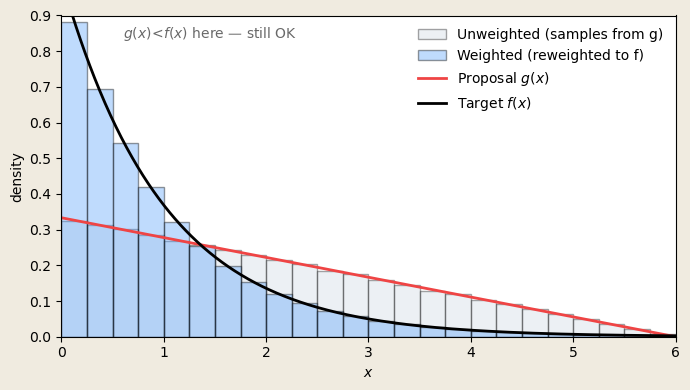

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Define target and proposal ---
def f_unnorm(x):
    return np.exp(-x) * (x >= 0)

def q_unnorm(x):
    return (1 - x/6.0) * ((x >= 0) & (x <= 6))

# Normalization constants
norm_f = np.trapz(f_unnorm(np.linspace(0, 6, 2000)), np.linspace(0, 6, 2000))
norm_q = np.trapz(q_unnorm(np.linspace(0, 6, 2000)), np.linspace(0, 6, 2000))

def f(x): return f_unnorm(x) / norm_f
def q(x): return q_unnorm(x) / norm_q

# --- Inverse CDF sampler for q ---
# For the unnormalized version: F(x) = x - x^2/12 (scaled to [0,6])
# After normalization, F_norm(x) = F(x)/∫ q dx = F(x)/norm_q
# Inverse: x = 6 - sqrt(36 - 12*u*norm_q)
def sample_q_linear(n):
    u = rng.random(n)
    return 6 - np.sqrt(36 - 12*u*norm_q)

# --- Draw samples and compute weights ---
N = 200_000
xq = sample_q_linear(N)

w = f(xq) / q(xq)
# Normalize weights so histogram area matches f
w /= np.mean(w)

# --- Prepare reference curves ---
xx = np.linspace(0, 6, 800)
ff = f(xx)
qq = q(xx)

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

bins = np.linspace(0, 6, 25)

# Unweighted: samples from g
ax.hist(xq, bins=bins, density=True, alpha=0.35, color='#cbd5e1',
        edgecolor='black', label='Unweighted (samples from g)')

# Weighted: same samples with weights w = f/g
ax.hist(xq, bins=bins, weights=w, density=True, alpha=0.40, color='#60a5fa',
        edgecolor='black', label='Weighted (reweighted to f)')

# Curves
ax.plot(xx, qq, color='#ef4444', lw=2, label=r'Proposal $g(x)$')
ax.plot(xx, ff,  color='black', lw=2, label=r'Target $f(x)$')

# Annotate
ax.text(0.1, 0.93, r'$g(x)\!<\!f(x)$ here — still OK', transform=ax.transAxes,
        fontsize=10, color='dimgray')

ax.set_xlim(0, 6)
ax.set_ylim(0, 0.9)
ax.set_xlabel(r'$x$')
ax.set_ylabel('density')
ax.legend(frameon=False, loc='upper right')

fig.savefig('reweighting-proposal.pdf')

plt.tight_layout()
plt.show()


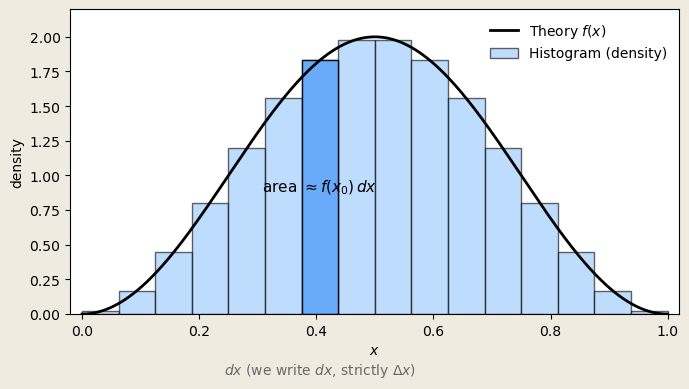

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Repro
rng = np.random.default_rng(12345)

# Target density (black curve) for illustration
def f(x):
    return 2.0 * np.sin(np.pi * x)**2  # on [0,1]

# Binning
n_bins = 16
edges = np.linspace(0.0, 1.0, n_bins + 1)
dx = edges[1] - edges[0]
centers = 0.5 * (edges[:-1] + edges[1:])

# "Histogram" bars via midpoint rule (to avoid MC noise)
heights = f(centers)

# Choose a bin to highlight
i_hi = 6
x0 = centers[i_hi]
y0 = f(x0)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# Bars (density-height style)
ax.bar(centers, heights, width=dx, align='center',
       facecolor='#93c5fd', edgecolor='black', alpha=0.6, label='Histogram (density)')

# Overlay theory curve
xx = np.linspace(0, 1, 800)
ax.plot(xx, f(xx), color='black', lw=2, label=r'Theory $f(x)$')

# Highlight one bin
ax.add_patch(Rectangle((x0 - dx/2, 0), dx, y0,
                       facecolor='#60a5fa', edgecolor='black', alpha=0.9))

# Annotations: dx, f(x0), area
ax.annotate(r'$dx$ (we write $dx$, strictly $\Delta x$)',
            xy=(x0, -0.04), xycoords=('data', 'axes fraction'),
            xytext=(0, -25), textcoords='offset points',
            ha='center', va='top', fontsize=10, color='dimgray')

ax.text(x0, 0.5*y0, r'area $\approx f(x_0)\,dx$',
        ha='center', va='center', fontsize=11, color='black')

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 2.2)
ax.set_xlabel(r'$x$')
ax.set_ylabel('density')
ax.legend(loc='upper right', frameon=False)
fig.savefig('histogram.pdf')
plt.tight_layout()
plt.show()


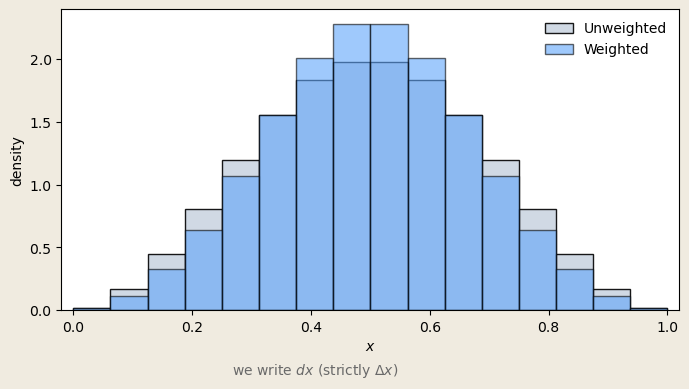

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Target pdf on [0,1]
def f(x):
    return 2.0 * np.sin(np.pi * x)**2  # integrates to 1 on [0,1]

# A simple illustrative weight field (e.g. upweight the middle a bit)
def w(x):
    return 1.0 + 0.8*np.exp(-0.5*((x-0.5)/0.18)**2)

# Binning
n_bins = 16
edges = np.linspace(0.0, 1.0, n_bins + 1)
dx = edges[1] - edges[0]
centers = 0.5*(edges[:-1] + edges[1:])

# --- Unweighted histogram (midpoint rule for illustration) ---
p_unw = f(centers) * dx                  # per-bin probability mass
p_unw /= p_unw.sum()                     # normalize Σ p = 1
h_unw = p_unw / dx                       # density = probability / dx

# --- Weighted histogram (binwise weighted sum, approximated at centers) ---
p_w = f(centers) * w(centers) * dx       # weighted per-bin mass (∝ Σ_i w_i in bin)
p_w /= p_w.sum()                         # normalize Σ p_w = 1
h_w = p_w / dx                           # density

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor("#F0EBE0")  # Set background color

# Unweighted bars
ax.bar(centers, h_unw, width=dx, align='center',
       color='#cbd5e1', edgecolor='black', alpha=0.9, label='Unweighted')

# Weighted bars (overlay)
ax.bar(centers, h_w, width=dx, align='center',
       color='#60a5fa', edgecolor='black', alpha=0.6, label='Weighted')

# Annotation for dx (note about Δx)
i = 6
x0 = centers[i]
ax.annotate(r'we write $dx$ (strictly $\Delta x$)',
            xy=(x0, -0.04), xycoords=('data', 'axes fraction'),
            xytext=(0, -28), textcoords='offset points',
            ha='center', va='top', fontsize=10, color='dimgray')

ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, None)
ax.set_xlabel(r'$x$')
ax.set_ylabel('density')
ax.legend(loc='upper right', frameon=False)
fig.savefig('weighted-histogram.pdf')
plt.tight_layout()
plt.show()


/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/1138086421.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ff /= np.trapz(ff, xx)
/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/1138086421.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gg /= np.trapz(gg, xx)


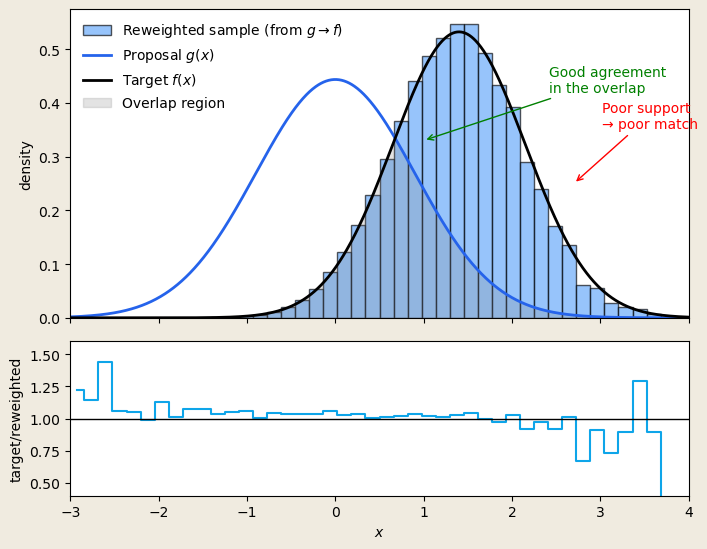

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

# --- Define target and proposal with SUBSTANTIAL OVERLAP ---
# Narrower, closer means -> a region where reweighting works well
def f(x): return np.exp(-0.5*((x - 1.4)/0.75)**2)          # target
def g(x): return np.exp(-0.5*((x - 0.0)/0.90)**2)           # proposal

xx = np.linspace(-3, 4, 1200)
ff, gg = f(xx), g(xx)
ff /= np.trapz(ff, xx)
gg /= np.trapz(gg, xx)

# --- Sample from g and compute weights w=f/g ---
N = 50_000
xg = rng.normal(loc=0.0, scale=0.90, size=N)   # proposal sampling matches g
wg = f(xg) / g(xg)
wg /= np.mean(wg)  # normalize weights so weighted density integrates ~1

# --- Histogram setup (shared for top + ratio) ---
bins = np.linspace(-3, 4, 45)
bin_centers = 0.5*(bins[:-1] + bins[1:])
# Target pdf at centers for the ratio (avoid division by ~0)
f_centers = np.interp(bin_centers, xx, ff)
f_centers = np.clip(f_centers, 1e-12, None)

# Weighted density (top panel) and ratio (bottom)
hist_w, _ = np.histogram(xg, bins=bins, weights=wg, density=True)
ratio = hist_w / f_centers

# --- Plot ---
fig, (ax, axr) = plt.subplots(2, 1, figsize=(7.2, 5.6), sharex=True,
                              gridspec_kw={'height_ratios':[2.0, 1.0]})

# Top: densities
ax.hist(xg, bins=bins, weights=wg, density=True,
        color='#60a5fa', alpha=0.65, edgecolor='black',
        label='Reweighted sample (from $g\\to f$)')

ax.plot(xx, gg, color='#2563eb', lw=2.0, label=r'Proposal $g(x)$')
ax.plot(xx, ff, color='black',   lw=2.0, label=r'Target $f(x)$')

# Shade overlap region
ax.fill_between(xx, np.minimum(ff, gg), color='gray', alpha=0.22, label='Overlap region')

ax.set_xlim(bins[0], bins[-1])
ax.set_ylim(0, None)
ax.set_ylabel('density')
ax.legend(frameon=False, loc='upper left')

# Bottom: ratio (reweighted / target)
axr.step(bin_centers, ratio, where='mid', color='#0ea5e9')
axr.axhline(1.0, color='black', lw=1)
axr.set_ylim(0.4, 1.6)
axr.set_ylabel('target/reweighted')
axr.set_xlabel(r'$x$')

# Annotations
ax.annotate("Good agreement\nin the overlap",
            xy=(1., 0.33), xycoords='data',
            xytext=(90, 35), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'),
            fontsize=10, color='green')
ax.annotate("Poor support\n→ poor match",
            xy=(2.7, 0.25), xycoords='data',
            xytext=(20, 40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')
fig.patch.set_facecolor("#F0EBE0")  # Set background color

fig.savefig('reweight-fail.pdf')

plt.tight_layout()
plt.show()


/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/327532027.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p /= np.trapz(p, xx)
/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_49420/327532027.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


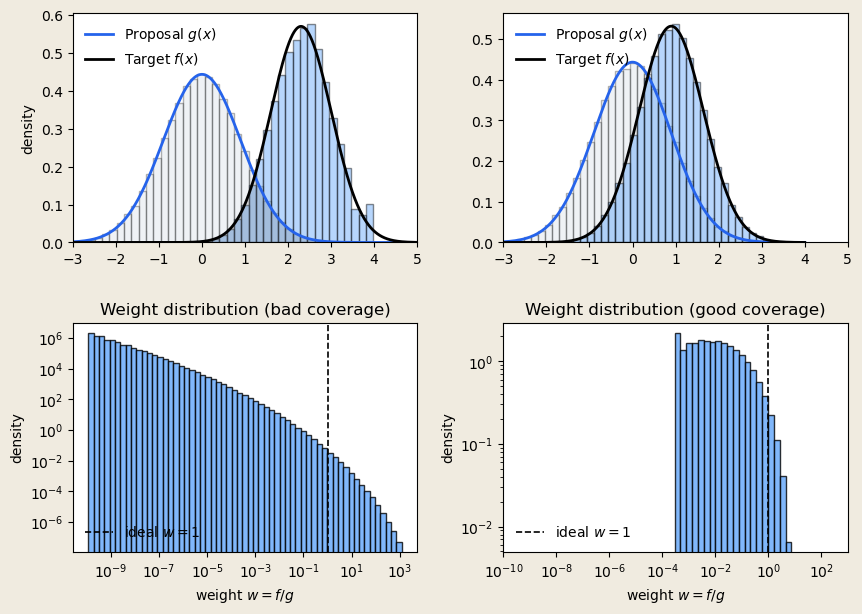

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(10)

def norm_pdf(xx, mu, sigma):
    p = np.exp(-0.5*((xx-mu)/sigma)**2)
    p /= np.trapz(p, xx)
    return p

# Grid for reference curves
xx_bad  = np.linspace(-3, 5, 1600)
xx_good = np.linspace(-3, 4, 1600)

# --- BAD CASE: poor overlap ---
f_bad = norm_pdf(xx_bad,  mu=2.3, sigma=0.70)   # target (black)
g_bad = norm_pdf(xx_bad,  mu=0.0, sigma=0.90)   # proposal (blue)

# Sample from g_bad and compute weights w = f/g
N_bad = 200_000
xg_bad = rng.normal(loc=0.0, scale=0.90, size=N_bad)
# Interpolate normalized densities at sample points
f_x_bad = np.interp(xg_bad, xx_bad, f_bad)
g_x_bad = np.interp(xg_bad, xx_bad, g_bad)
w_bad   = f_x_bad / np.clip(g_x_bad, 1e-300, None)  # raw weights, no renorm

# --- GOOD CASE: decent overlap ---
f_good = norm_pdf(xx_good, mu=0.9, sigma=0.75)
g_good = norm_pdf(xx_good, mu=0.0, sigma=0.90)

N_good = 200_000
xg_good = rng.normal(loc=0.0, scale=0.90, size=N_good)
f_x_good = np.interp(xg_good, xx_good, f_good)
g_x_good = np.interp(xg_good, xx_good, g_good)
w_good   = f_x_good / np.clip(g_x_good, 1e-300, None)

# --- Figure: 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(10, 7), gridspec_kw={'hspace':0.35, 'wspace':0.25})

# -------------------------
# Upper Left: BAD reweighting
# -------------------------
ax = axes[0,0]
bins_bad = np.linspace(xx_bad[0], xx_bad[-1], 48)

# Unweighted (shows proposal q=g)
ax.hist(xg_bad, bins=bins_bad, density=True, alpha=0.30, color='#cbd5e1',
        edgecolor='black')

# Weighted (should match f where overlap exists)
ax.hist(xg_bad, bins=bins_bad, weights=w_bad, density=True, alpha=0.45, color='#60a5fa',
        edgecolor='black')

# Curves
ax.plot(xx_bad, g_bad, color='#2563eb', lw=2, label=r'Proposal $g(x)$')
ax.plot(xx_bad, f_bad, color='black',   lw=2, label=r'Target $f(x)$')

# Overlap shading
ax.fill_between(xx_bad, np.minimum(f_bad, g_bad), color='gray', alpha=0.22)

ax.set_xlim(-3,5)
ax.set_ylim(0, None)
ax.set_ylabel('density')
ax.legend(frameon=False, loc='upper left')

# -------------------------
# Lower Left: BAD weights (log–log)
# -------------------------
ax = axes[1,0]
# Positive bins for log–log
wb = np.clip(w_bad, 1e-12, None)
bins_w_bad = np.logspace(np.log10(wb.min()), np.log10(wb.max()), 60)
ax.hist(wb, bins=bins_w_bad, density=True, color='#60a5fa', alpha=0.8, edgecolor='black')
ax.axvline(1.0, color='black', lw=1.2, ls='--', label=r'ideal $w=1$')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(r'weight $w=f/g$'); ax.set_ylabel('density')
ax.set_title('Weight distribution (bad coverage)')
ax.legend(frameon=False, loc='lower left')

# -------------------------
# Upper Right: GOOD reweighting
# -------------------------
ax = axes[0,1]
bins_good = np.linspace(xx_good[0], xx_good[-1], 44)

ax.hist(xg_good, bins=bins_good, density=True, alpha=0.30, color='#cbd5e1',
        edgecolor='black')
ax.hist(xg_good, bins=bins_good, weights=w_good, density=True, alpha=0.45, color='#60a5fa',
        edgecolor='black')

ax.plot(xx_good, g_good, color='#2563eb', lw=2, label=r'Proposal $g(x)$')
ax.plot(xx_good, f_good, color='black',   lw=2, label=r'Target $f(x)$')

ax.set_xlim(-3,5)
ax.set_ylim(0, None)
ax.legend(frameon=False, loc='upper left')

# -------------------------
# Lower Right: GOOD weights (log–log)
# -------------------------
ax = axes[1,1]
wg = np.clip(w_good, 1e-12, None)
bins_w_good = np.logspace(np.log10(wg.min()), np.log10(wg.max()), 60)
ax.hist(wg, bins=bins_w_bad, density=True, color='#60a5fa', alpha=0.8, edgecolor='black')
ax.axvline(1.0, color='black', lw=1.2, ls='--', label=r'ideal $w=1$')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(1e-10,1e3)
ax.set_xlabel(r'weight $w=f/g$'); ax.set_ylabel('density')
ax.set_title('Weight distribution (good coverage)')
ax.legend(frameon=False, loc='lower left')
fig.patch.set_facecolor("#F0EBE0")  # Set background color

fig.savefig('reweight-weights.pdf')
plt.tight_layout()
plt.show()


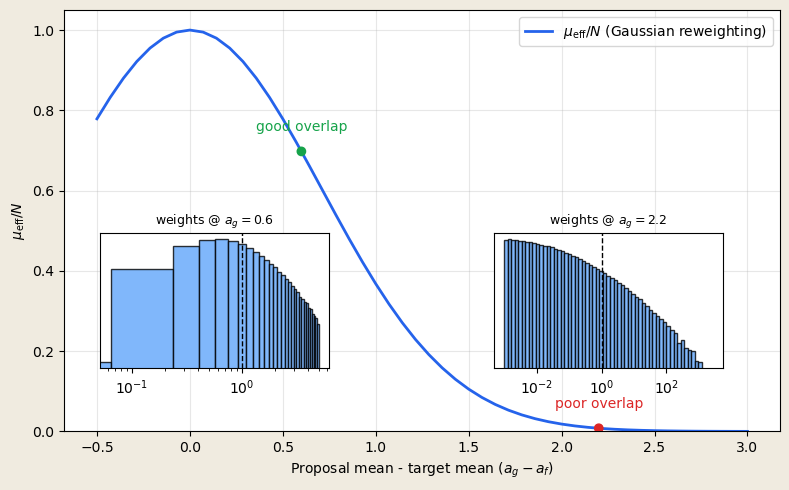

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

# --- Proposal and target: same width, different means (normal units) ---
sigma = 1.0
mu_g  = 0.0  # proposal mean (fixed)

# Analytic ESS/N for Gaussians with same sigma:
# mu_eff/N = exp( - (mu_f - mu_g)^2 / sigma^2 )
def mu_eff_frac(mu_f):
    return np.exp( - ((mu_f - mu_g)**2) / (sigma**2) )

# Scan target means
mu_f_vals = np.linspace(-0.5, 3.0, 50)
mu_fracs  = mu_eff_frac(mu_f_vals)

# Choose representative "good" and "bad" overlap targets for insets
mu_good = 0.6     # close to proposal mean
mu_bad  = 2.2     # far from proposal mean

# Function to sample weights w = f/g for given target mean (for inset histograms)
def sample_weights(mu_f, N=200_000):
    # x ~ N(mu_g, sigma)
    x = rng.normal(loc=mu_g, scale=sigma, size=N)
    # For equal sigmas, the ratio simplifies analytically:
    # w = exp( (mu_f - mu_g) * x / sigma^2 - (mu_f^2 - mu_g^2)/(2 sigma^2) )
    delta = mu_f - mu_g
    w = np.exp( (delta * x) / (sigma**2) - (mu_f**2 - mu_g**2) / (2 * sigma**2) )
    return w

# Prepare inset data
w_good = sample_weights(mu_good)
w_bad  = sample_weights(mu_bad)

# --- Plot main ESS curve with two insets for weight distributions ---
fig, ax = plt.subplots(figsize=(8, 5))

# Main curve
ax.plot(mu_f_vals, mu_fracs, color='#2563eb', lw=2,label=r'$\mu_{\mathrm{eff}}/N$ (Gaussian reweighting)')
ax.scatter([mu_good, mu_bad], [mu_eff_frac(mu_good), mu_eff_frac(mu_bad)],
           color=['#16a34a','#dc2626'], zorder=3)

ax.set_xlabel(r'Proposal mean - target mean ($a_g - a_f$)')
ax.set_ylabel(r'$\mu_{\mathrm{eff}}/N$')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
# Annotate good/bad markers
ax.text(mu_good, mu_eff_frac(mu_good)+0.05, 'good overlap', color='#16a34a', ha='center')
ax.text(mu_bad,  mu_eff_frac(mu_bad)+0.05,  'poor overlap', color='#dc2626', ha='center')

# Inset: weight histogram for GOOD overlap (log-log)
ax_in_good = ax.inset_axes([0.05, 0.15, 0.32, 0.32])
bins_good = np.logspace(np.log10(max(1e-3, w_good.min())),
                        np.log10(max(1e-3, w_good.max())), 60)
ax_in_good.hist(w_good, bins=bins_bad, density=True, color='#60a5fa',
                alpha=0.8, edgecolor='black')
ax_in_good.axvline(1.0, color='black', lw=1, ls='--')
ax_in_good.set_xscale('log'); ax_in_good.set_yscale('log')
ax_in_good.set_title(fr'weights @ $a_g={mu_good:.1f}$', fontsize=9)
ax_in_good.set_yticks([])

# Inset: weight histogram for BAD overlap (log-log)
ax_in_bad = ax.inset_axes([0.60, 0.15, 0.32, 0.32])
bins_bad = np.logspace(np.log10(max(1e-3, w_bad.min())),
                       np.log10(max(1e-3, w_bad.max())), 60)
ax_in_bad.hist(w_bad, bins=bins_bad, density=True, color='#60a5fa',
               alpha=0.8, edgecolor='black')
ax_in_bad.axvline(1.0, color='black', lw=1, ls='--')
ax_in_bad.set_xscale('log'); ax_in_bad.set_yscale('log')
ax_in_bad.set_title(fr'weights @ $a_g={mu_bad:.1f}$', fontsize=9)
ax_in_bad.set_yticks([])
fig.patch.set_facecolor("#F0EBE0")  # Set background color

fig.savefig('mu-eff.pdf')
plt.tight_layout()
plt.tight_layout()
plt.show()


/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_41011/2627907395.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ff = f(xx) / np.trapz(f(xx), xx)  # already normalized to 1
/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_41011/2627907395.py:99: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Zg = np.trapz(val, x) if np.ndim(x)>0 else 1.25  # approximate norm if vector
/var/folders/3p/st4pq4bs01107rspk9yxjdq40000gn/T/ipykernel_41011/2627907395.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


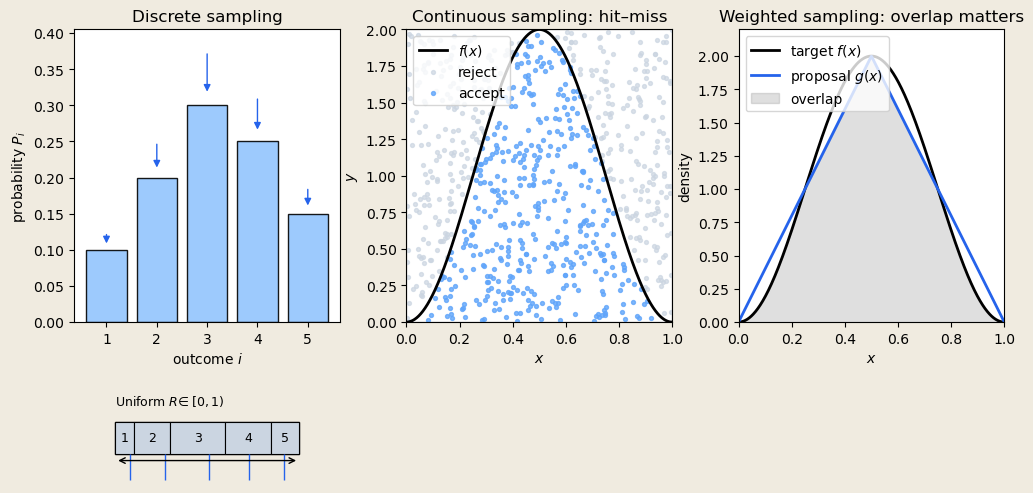

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.gridspec import GridSpec

rng = np.random.default_rng(12345)

fig = plt.figure(figsize=(12, 3.8))
gs  = GridSpec(1, 3, figure=fig, wspace=0.25)

# ----------------------------------------------------------
# LEFT: Discrete sampling — probabilities and CDF partition
# ----------------------------------------------------------
ax = fig.add_subplot(gs[0, 0])

# Example discrete distribution (5 outcomes)
labels = np.arange(1, 6)
P      = np.array([0.10, 0.20, 0.30, 0.25, 0.15])
P     /= P.sum()

# Bars (probabilities)
ax.bar(labels, P, color='#93c5fd', edgecolor='black', alpha=0.9)
ax.set_ylim(0, max(P)*1.35)
ax.set_xticks(labels)
ax.set_xlabel('outcome $i$')
ax.set_ylabel('probability $P_i$')
ax.set_title('Discrete sampling')

# Draw a CDF strip below the axis to show mapping R -> bins
ax_cdf = ax.inset_axes([0.12, -0.55, 0.76, 0.22])  # [x0,y0,w,h] in axes coords
ax_cdf.axis('off')
x0 = 0.05
width = 0.90
ax_cdf.add_patch(Rectangle((x0, 0.35), width, 0.25, facecolor='white', edgecolor='black', lw=1))
c = np.cumsum(P)
edges = np.concatenate(([0], c))
# Fill segments for each outcome
colors = ['#cbd5e1', '#cbd5e1', '#cbd5e1', '#cbd5e1', '#cbd5e1']
for i in range(len(P)):
    ax_cdf.add_patch(Rectangle((x0 + width*edges[i], 0.35),
                               width*(edges[i+1] - edges[i]), 0.25,
                               facecolor=colors[i], edgecolor='black', lw=0.8))
    ax_cdf.text(x0 + width*(edges[i] + edges[i+1])/2, 0.475, f'{labels[i]}',
                ha='center', va='center', fontsize=9)

ax_cdf.text(x0, 0.70, r'Uniform $R\!\in[0,1)$', ha='left', va='bottom', fontsize=9)
ax_cdf.annotate('', xy=(x0+width, 0.30), xytext=(x0, 0.30),
                arrowprops=dict(arrowstyle='<->', lw=1))
# A few example R values and arrows into bars
R_samples = np.array([0.08, 0.27, 0.51, 0.73, 0.92])
for R in R_samples:
    xp = x0 + width*R
    ax_cdf.vlines(xp, 0.35, 0.15, colors='#2563eb', lw=1)
    # Map to outcome index
    i = np.searchsorted(c, R) + 1
    ax.annotate('', xy=(i, P[i-1]*1.05), xytext=(i, P[i-1]*1.25),
                arrowprops=dict(arrowstyle='-|>', color='#2563eb', lw=1))

# ----------------------------------------------------------
# MIDDLE: Continuous — hit–miss illustration
# ----------------------------------------------------------
ax = fig.add_subplot(gs[0, 1])

# Target pdf on [0,1]: f(x) = 2 sin^2(pi x) (normalized)
def f(x): return 2.0*np.sin(np.pi*x)**2

xx = np.linspace(0, 1, 800)
ax.plot(xx, f(xx), color='black', lw=2, label=r'$f(x)$')

# Box for hit–miss
ymax = 2.0
ax.add_patch(Rectangle((0, 0), 1, ymax, fill=False, edgecolor='black', lw=0.8))

# Sample a modest number of points for a clean figure
M = 800
xs = rng.random(M)
ys = rng.random(M) * ymax
accepted = ys < f(xs)

ax.scatter(xs[~accepted], ys[~accepted], s=8, color='#cbd5e1', alpha=0.7, label='reject')
ax.scatter(xs[ accepted], ys[ accepted], s=8, color='#60a5fa', alpha=0.8, label='accept')

ax.set_xlim(0, 1)
ax.set_ylim(0, ymax)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.set_title('Continuous sampling: hit–miss')
ax.legend(frameon=True, loc='upper left')

# ----------------------------------------------------------
# RIGHT: Weighted sampling — overlap f vs g
# ----------------------------------------------------------
ax = fig.add_subplot(gs[0, 2])

# Target f (black) and piecewise triangular proposal g (blue), both on [0,1]
def g(x):
    x = np.asarray(x)
    val = np.where(x < 0.5, 5*x, -5*x + 5)   # unnormalized
    Zg = np.trapz(val, x) if np.ndim(x)>0 else 1.25  # approximate norm if vector
    return val / 1.25  # exact normalization ∫g = 1.25 on [0,1]

xx = np.linspace(0, 1, 800)
ff = f(xx) / np.trapz(f(xx), xx)  # already normalized to 1
gg = g(xx)

ax.plot(xx, ff, color='black', lw=2, label=r'target $f(x)$')
ax.plot(xx, gg, color='#2563eb', lw=2, label=r'proposal $g(x)$')

# Shade overlap region
ax.fill_between(xx, np.minimum(ff, gg), color='gray', alpha=0.25, label='overlap')

ax.set_xlim(0, 1)
ax.set_ylim(0, max(ff.max(), gg.max())*1.1)
ax.set_xlabel('$x$')
ax.set_ylabel('density')
ax.set_title('Weighted sampling: overlap matters')
ax.legend(frameon=True, loc='upper left')
fig.patch.set_facecolor("#F0EBE0")  # Set background color

fig.savefig('summary.pdf')
plt.tight_layout()
plt.show()
